<div style="background: linear-gradient(135deg, #1a0a09 0%, #2d1a19 50%, #1a0a09 100%); color: #f19bea; padding: 30px; border-radius: 20px; text-align: center; border: 2px solid #f19bea; box-shadow: 0 0 40px rgba(241,155,234,0.3); font-family: 'Segoe UI', sans-serif; margin-bottom: 10px;">
  <h1 style="font-size: 200%; margin: 0 0 10px 0; letter-spacing: 2px;">🧬 Cancer Genome Atlas</h1>
  <h2 style="font-size: 140%; margin: 0 0 15px 0; color: #ffd6f7; font-weight: normal;">Predictive Analytics & Classification Project</h2>
  <div style="border-top: 1px solid rgba(241,155,234,0.4); padding-top: 15px; font-size: 95%; color: #ffd6f7; opacity: 0.85; line-height: 1.8;">
    <b>Dataset:</b> UCSC Xena — TCGA Pan-Cancer (PANCAN) &nbsp;|&nbsp; <b>Samples:</b> ~10,000+ patients &nbsp;|&nbsp; <b>Genes:</b> 20,530+<br>
    <b>Cancer Types:</b> 33 TCGA tumor types &nbsp;|&nbsp; <b>Task:</b> Multi-class Classification + EDA
  </div>
</div>

<div style="background-color: #2d1a19; color: #f19bea; padding: 20px 30px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 120%; display: block; margin-bottom: 12px;">📋 Project Roadmap</b>
  <ul style="list-style-type: none; margin: 0; padding: 0; line-height: 2; font-size: 105%;">
    <li>⚙️ &nbsp;<b>Phase 1</b> — Environment Setup & Data Loading</li>
    <li>🔬 &nbsp;<b>Phase 2</b> — Data Cleaning & Quality Control</li>
    <li>📊 &nbsp;<b>Phase 3</b> — Descriptive Statistics</li>
    <li>🎨 &nbsp;<b>Phase 4</b> — Exploratory Data Analysis (EDA)</li>
  </ul>
</div>

<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: flex; align-items: center; margin-bottom: 15px;">⚙️ Environment Setup & Library Imports</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">We import all necessary libraries for the entire project pipeline in a single organized cell. This follows best practices by declaring all dependencies upfront, making the notebook reproducible and easy to audit.</p>
  <ul style="list-style-type: square; margin-left: 35px; line-height: 1.8; font-size: 105%;">
    <li><b>pandas / numpy</b> — Data manipulation and numerical computation</li>
    <li><b>matplotlib / seaborn / plotly</b> — Static and interactive visualizations</li>
    <li><b>scikit-learn</b> — Machine learning: PCA, classification, evaluation</li>
    <li><b>warnings</b> — Suppress non-critical warnings for clean output</li>
  </ul>
</div>

In [1]:
# ============================================================
# PHASE 1: ENVIRONMENT SETUP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import gc



<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">📂 Data Loading</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">Loading the two main files from the UCSC Xena TCGA Pan-Cancer dataset: the gene expression matrix and the phenotype file containing cancer type labels.</p>
</div>

In [3]:
print("Loading Gene Expression Data...")

# 1. تحميل البيانات
gene_data = pd.read_csv(
    "/content/EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena",
    sep='\t'
).set_index('sample')

# 2. المكان الذهبي: تحويل الدقة هنا قبل أي عمليات معقدة
gene_data = gene_data.astype('float32')

gene_data = gene_data.T

print(f"Gene data shape: {gene_data.shape} (patients × genes)")

Loading Gene Expression Data...
Gene data shape: (11069, 20531) (patients × genes)


In [4]:
print("Loading Phenotype Labels...")

# Load survival/phenotype file (tab-separated, uncompressed)
pheno_data = pd.read_csv(
    "/content/Survival_SupplementalTable_S1_20171025_xena_sp",
    sep='\t'
)

print(f"Phenotype data shape: {pheno_data.shape}")
print(f"Columns available: {list(pheno_data.columns[:8])} ...")

Loading Phenotype Labels...
Phenotype data shape: (12591, 34)
Columns available: ['sample', '_PATIENT', 'cancer type abbreviation', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'clinical_stage'] ...


In [5]:
# Standardize the join key to 'sampleID' in both datasets
pheno_data = pheno_data.rename(columns={'sample': 'sampleID'})
gene_data.index.name = 'sampleID'

print("Sample ID column aligned in both datasets — ready to merge.")

Sample ID column aligned in both datasets — ready to merge.


<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">🔗 Merging Datasets</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">Performing an inner join between gene expression data and phenotype labels on sampleID to create a unified dataframe.</p>
</div>

In [6]:
print("Merging datasets...")

TARGET_COL = 'cancer type abbreviation'

# Inner join on sampleID — keeps only matched samples
final_df = pd.merge(
    gene_data,
    pheno_data[['sampleID', TARGET_COL]],
    on='sampleID'
)

print(f"Merged dataset shape: {final_df.shape}  (patients × [genes + label columns])")
display(final_df.head(3))

Merging datasets...
Merged dataset shape: (11014, 20533)  (patients × [genes + label columns])


,sampleID,100130426,100133144,100134869,10357,10431,136542,155060,26823,280660,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,cancer type abbreviation
0,TCGA-OR-A5J1-01,0.0,2.09,2.30,7.23,10.99,0.0,8.10,1.29,0.0,...,7.21,4.44,8.46,10.04,0.57,9.34,10.85,10.18,9.22,ACC
1,TCGA-OR-A5J2-01,0.0,1.88,3.32,6.36,10.35,0.0,7.65,0.00,0.0,...,8.78,5.86,8.13,11.54,5.02,10.19,11.58,10.89,9.65,ACC
2,TCGA-OR-A5J3-01,0.0,1.45,2.92,6.45,10.04,0.0,8.45,0.67,0.0,...,7.58,5.35,8.96,9.84,0.67,9.66,11.38,10.53,8.78,ACC


In [7]:
# بعد الـ merge مباشرة
del gene_data
del pheno_data
gc.collect() # إجبار النظام على تفريغ الرام فوراً

0

<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">🗂️ Cancer Type Mapping (English + Arabic)</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">Mapping cancer abbreviations to their full clinical names in both English and Arabic for better interpretability.</p>
</div>

In [8]:
# Dictionary: abbreviation → (English name, Arabic name)
cancer_map_en = {
    'ACC': 'Adrenocortical Carcinoma',
    'BLCA': 'Bladder Urothelial Carcinoma',
    'BRCA': 'Breast Invasive Carcinoma',
    'CESC': 'Cervical Squamous Cell Carcinoma',
    'CHOL': 'Cholangiocarcinoma',
    'COAD': 'Colon Adenocarcinoma',
    'DLBC': 'Diffuse Large B-cell Lymphoma',
    'ESCA': 'Esophageal Carcinoma',
    'GBM': 'Glioblastoma Multiforme',
    'HNSC': 'Head and Neck Squamous Cell Carcinoma',
    'KICH': 'Kidney Chromophobe',
    'KIRC': 'Kidney Renal Clear Cell Carcinoma',
    'KIRP': 'Kidney Renal Papillary Cell Carcinoma',
    'LAML': 'Acute Myeloid Leukemia',
    'LGG': 'Brain Lower Grade Glioma',
    'LIHC': 'Liver Hepatocellular Carcinoma',
    'LUAD': 'Lung Adenocarcinoma',
    'LUSC': 'Lung Squamous Cell Carcinoma',
    'MESO': 'Mesothelioma',
    'OV': 'Ovarian Serous Cystadenocarcinoma',
    'PAAD': 'Pancreatic Adenocarcinoma',
    'PCPG': 'Pheochromocytoma and Paraganglioma',
    'PRAD': 'Prostate Adenocarcinoma',
    'READ': 'Rectum Adenocarcinoma',
    'SARC': 'Sarcoma',
    'SKCM': 'Skin Cutaneous Melanoma',
    'STAD': 'Stomach Adenocarcinoma',
    'TGCT': 'Testicular Germ Cell Tumors',
    'THCA': 'Thyroid Carcinoma',
    'THYM': 'Thymoma',
    'UCEC': 'Uterine Corpus Endometrial Carcinoma',
    'UCS': 'Uterine Carcinosarcoma',
    'UVM': 'Uveal Melanoma'
}

cancer_map_ar = {
    'ACC': 'سرطان قشرة الأدرينال',
    'BLCA': 'سرطان المثانة',
    'BRCA': 'سرطان الثدي',
    'CESC': 'سرطان عنق الرحم الحرشفي',
    'CHOL': 'سرطان القنوات الصفراوية',
    'COAD': 'سرطان القولون',
    'DLBC': 'سرطان الغدد الليمفاوية ب المساعد',
    'ESCA': 'سرطان المريء',
    'GBM': 'سرطان الدماغ - إسفنجي',
    'HNSC': 'سرطان الرأس والرقبة',
    'KICH': 'سرطان الكلى - فوبيا',
    'KIRC': 'سرطان الكلى - خلايا صافية',
    'KIRP': 'سرطان الكلى الحليمي',
    'LAML': 'سرطان الدم النخاعي الحاد',
    'LGG': 'سرطان الدماغ - درجة منخفضة',
    'LIHC': 'سرطان الكبد',
    'LUAD': 'سرطان الرئة الغدي',
    'LUSC': 'سرطان الرئة الحرشفي',
    'MESO': 'ورم المتوسطة',
    'OV': 'سرطان المبيض',
    'PAAD': 'سرطان البنكرياس',
    'PCPG': 'ورم القواتم وجنيب العقد العصبية',
    'PRAD': 'سرطان البروستاتا',
    'READ': 'سرطان المستقيم',
    'SARC': 'ساركوما (الأنسجة الضامة)',
    'SKCM': 'سرطان الجلد - ميلانوما',
    'STAD': 'سرطان المعدة',
    'TGCT': 'أورام الخلايا الجرثومية الخصوية',
    'THCA': 'سرطان الغدة الدرقية',
    'THYM': 'ورم غدة التوتة',
    'UCEC': 'سرطان جسم الرحم',
    'UCS': 'ساركوما رحمية مسرطنة',
    'UVM': 'ميلانوما عنبية (العين)'
}
# Add two separate mapping columns: one English, one Arabic
final_df['cancer_name_en'] = final_df['cancer type abbreviation'].map(cancer_map_en)
final_df['cancer_name_ar'] = final_df['cancer type abbreviation'].map(cancer_map_ar)

# Preview the mapping
final_df[['sampleID', 'cancer type abbreviation', 'cancer_name_en', 'cancer_name_ar']].head(8)

,sampleID,cancer type abbreviation,cancer_name_en,cancer_name_ar
0,TCGA-OR-A5J1-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال
1,TCGA-OR-A5J2-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال
2,TCGA-OR-A5J3-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال
3,TCGA-OR-A5J5-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال
4,TCGA-OR-A5J6-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال
5,TCGA-OR-A5J7-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال
6,TCGA-OR-A5J8-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال
7,TCGA-OR-A5J9-01,ACC,Adrenocortical Carcinoma,سرطان قشرة الأدرينال


<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">🧹 Memory Cleanup & Dataset Overview</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">Freeing up memory and displaying a high-level summary of the dataset.</p>
</div>

In [9]:
import gc
gc.collect()

31

In [10]:
# Separate the feature matrix from metadata columns
META_COLS = ['sampleID', 'cancer type abbreviation', 'cancer_name_en', 'cancer_name_ar']
X = final_df.drop(columns=META_COLS, errors='ignore')

# Build a quick summary table
data_summary = pd.DataFrame({
    'Metric': ['Total Patients', 'Total Genes', 'Unique Cancer Types', 'Memory Usage (MB)'],
    'Value': [
        final_df.shape[0],
        X.shape[1],
        final_df['cancer type abbreviation'].nunique(),
        f"{final_df.memory_usage(deep=True).sum() / 1e6:.2f}"
    ]
})

print("Dataset Overview:")
display(data_summary)

Dataset Overview:


,Metric,Value
0,Total Patients,11014
1,Total Genes,20531
2,Unique Cancer Types,33
3,Memory Usage (MB),907.74


In [11]:
print("Missing values per column:")
display(final_df.isnull().sum())

print("\nTotal missing values in the entire DataFrame:")
print(final_df.isnull().sum().sum())

Missing values per column:


,0
sampleID,0
100130426,1716
100133144,0
100134869,0
10357,0
...,...
ZZEF1,0
ZZZ3,0
cancer type abbreviation,0
cancer_name_en,0



Total missing values in the entire DataFrame:
3968713


<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">🔬 Phase 2: Data Cleaning & Quality Control</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">Ensuring data quality by handling missing values, duplicates, sparsity, and invalid negative values.</p>
</div>

In [12]:
# --- Check 1: Missing values ---
null_before = final_df.isnull().sum().sum()
print(f"Missing values BEFORE cleaning : {null_before}")

# Fill all NaN with 0 (unexpressed genes treated as zero)
final_df = final_df.fillna(0)

null_after = final_df.isnull().sum().sum()
print(f"Missing values AFTER  cleaning : {null_after}")

Missing values BEFORE cleaning : 3968713
Missing values AFTER  cleaning : 0


In [13]:
# --- Check 2: Duplicate patient IDs ---
duplicate_count = final_df.duplicated(subset=['sampleID']).sum()
print(f"Duplicate sampleIDs: {duplicate_count}")

Duplicate sampleIDs: 0


In [14]:
# --- Check 3: Final shape confirmation ---
print(f"Final dataset shape after cleaning: {final_df.shape}")

Final dataset shape after cleaning: (11014, 20535)


<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">📋 Data Integrity Audit</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">Comprehensive quality report including missing values, duplicates, sparsity, and negative values check.</p>
</div>

In [15]:
# Rebuild X after filling NaN
X = final_df.drop(columns=META_COLS, errors='ignore')

# Integrity audit table
integrity_report = pd.DataFrame({
    'Check': ['Missing Values', 'Duplicate SampleIDs', 'Zero-Value Cells', 'Negative Values'],
    'Result': [
        final_df.isnull().sum().sum(),
        final_df.duplicated(subset=['sampleID']).sum(),
        int((X == 0).sum().sum()),
        int((X < 0).sum().sum())          # RNA-Seq values should not be negative
    ]
})

print("Data Integrity Audit Report:")
display(integrity_report)

Data Integrity Audit Report:


,Check,Result
0,Missing Values,0
1,Duplicate SampleIDs,0
2,Zero-Value Cells,32005675
3,Negative Values,1241991


In [16]:
# Sparsity = proportion of zero values across the entire gene matrix
zero_percentage = (X == 0).mean().mean() * 100
print(f"Sparsity: {zero_percentage:.2f}% of the gene matrix contains zeros.")

Sparsity: 14.15% of the gene matrix contains zeros.


<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">🎨 Exploratory Data Analysis (EDA)</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">Visual exploration of the data to discover patterns, distributions, and biological insights before modeling.</p>
</div>

In [17]:
# Percentage distribution of cancer types
dist_df = (
    final_df['cancer type abbreviation']
    .value_counts(normalize=True)
    .reset_index()
)
dist_df.columns = ['Cancer Type', 'Percentage']
dist_df['Percentage'] = dist_df['Percentage'].map(lambda x: f"{x*100:.2f}%")

print("Top 10 Cancer Types by Percentage:")
display(dist_df.head(10))

Top 10 Cancer Types by Percentage:


,Cancer Type,Percentage
0,BRCA,11.03%
1,KIRC,5.50%
2,LUAD,5.23%
3,THCA,5.19%
4,HNSC,5.14%
5,UCEC,5.04%
6,LUSC,5.01%
7,PRAD,4.99%
8,LGG,4.80%
9,COAD,4.47%


<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">📊 Phase 3 — Descriptive Statistics</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">Before visualizing, we compute core statistical summaries to understand the numeric landscape of the data:</p>
</div>Summary statistics (mean, std, min, max) for a sample of genes.

In [18]:
# Stats for first 5 genes — a quick sanity check on data scale
stats_table = X.iloc[:, :5].describe().T
print("Descriptive Statistics — First 5 Genes:")
display(stats_table)

Descriptive Statistics — First 5 Genes:


,count,mean,std,min,25%,50%,75%,max
100130426,11014.0,0.024768,0.137723,-0.14,0.00,0.00,0.00,4.25
100133144,11014.0,3.011148,1.403282,-1.08,2.15,3.14,4.00,7.56
100134869,11014.0,3.205047,1.191814,-1.05,2.48,3.27,4.00,8.66
10357,11014.0,7.034835,0.912902,0.00,6.43,6.96,7.59,10.96
10431,11014.0,9.839009,0.551858,7.87,9.47,9.82,10.20,12.74


<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">🔗 Correlation Matrix — Top 12 Variable Genes</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">This heatmap shows the pairwise correlations between the 12 most variable genes. High correlation (red) indicates genes that tend to change together, which may suggest redundancy and help in feature selection or dimensionality reduction.</p>
</div>

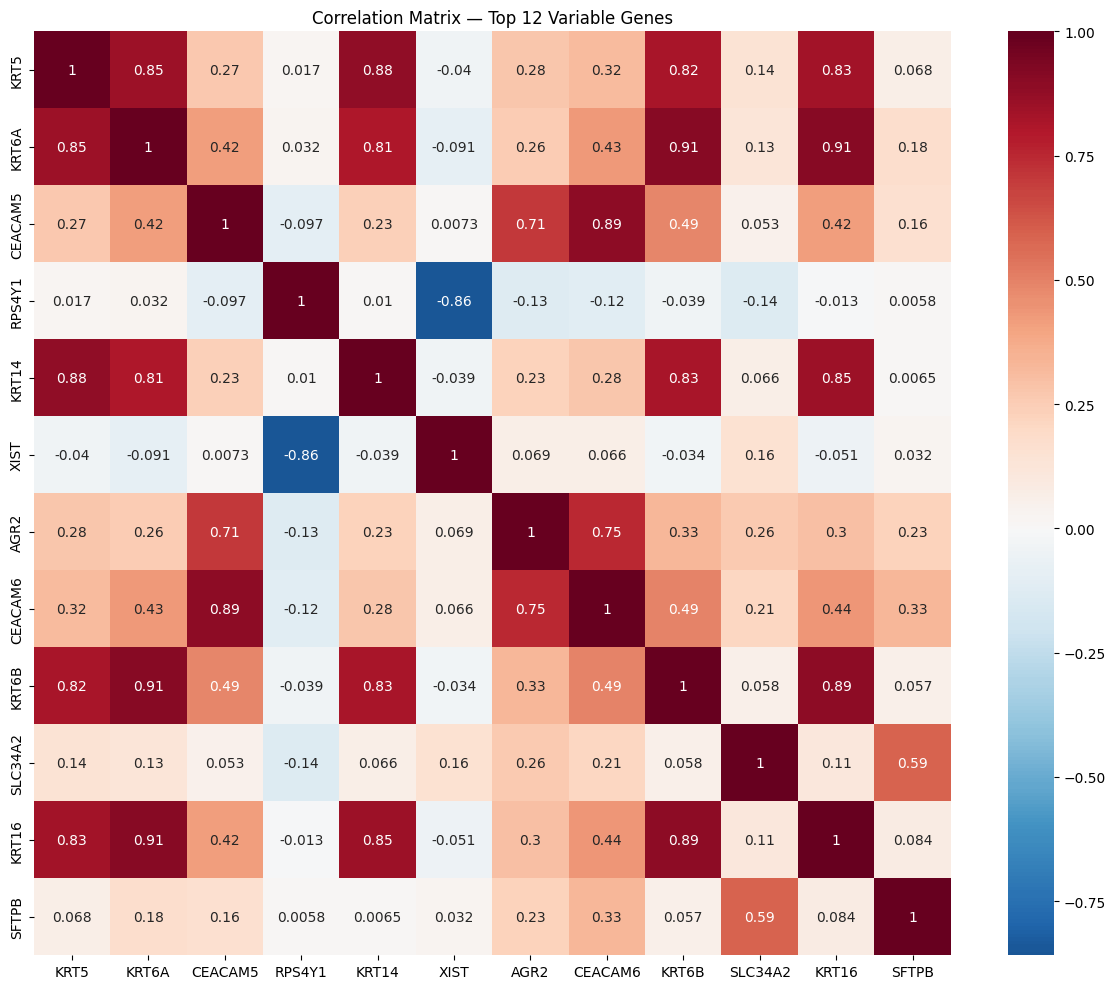

In [19]:
# Extended correlation heatmap — top 12 variable genes
top_genes_12 = X.std().sort_values(ascending=False).head(12).index
corr_mat_12 = X[top_genes_12].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_mat_12, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Matrix — Top 12 Variable Genes')
plt.tight_layout()
plt.show()

<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">🧬 Top 10 Expressed Genes: BRCA vs LUAD Comparison</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">Comparative analysis of the highest expressed genes in Breast Invasive Carcinoma (BRCA) and Lung Adenocarcinoma (LUAD). This helps identify cancer-type-specific gene expression patterns.</p>
</div>

In [20]:
brca_data = final_df[final_df['cancer type abbreviation'] == 'BRCA'][X.columns]
luad_data = final_df[final_df['cancer type abbreviation'] == 'LUAD'][X.columns]

brca_means = brca_data.mean().sort_values(ascending=False)
luad_means = luad_data.mean().sort_values(ascending=False)

comparison_table = pd.DataFrame({
    'Top Genes in BRCA': brca_means.head(10).index,
    'BRCA Mean Exp': brca_means.head(10).values,
    'Top Genes in LUAD': luad_means.head(10).index,
    'LUAD Mean Exp': luad_means.head(10).values
})

print("Top 10 Expressed Genes: BRCA vs LUAD Comparison Table")
display(comparison_table.style.background_gradient(cmap='YlGnBu'))

Top 10 Expressed Genes: BRCA vs LUAD Comparison Table


,Top Genes in BRCA,BRCA Mean Exp,Top Genes in LUAD,LUAD Mean Exp
0,ACTB,16.432222,ACTB,16.813473
1,EEF1A1,16.295424,FTL,16.310608
2,COL1A1,16.227825,SFTPB,16.152639
3,ACTG1,16.099226,EEF1A1,16.113335
4,COL1A2,15.885063,ACTG1,16.064062
5,FN1,15.838939,CD74,16.061407
6,COL3A1,15.767927,ADAM6,15.946876
7,EEF2,15.453382,B2M,15.847239
8,GAPDH,15.443439,TPT1,15.817623
9,TPT1,15.410963,FN1,15.604843


<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">⚙️ Preprocessing & Dimensionality Reduction</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">Standardizing features, removing low-variance genes, and applying PCA for dimensionality reduction.</p>
</div>

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Standardization complete — Mean ≈ 0, Std ≈ 1")
print(f"X_scaled shape: {X_scaled.shape}")

Standardization complete — Mean ≈ 0, Std ≈ 1
X_scaled shape: (11014, 20531)


<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">📉 9.2 Dimensionality Reduction — Step 1: Variance Thresholding</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">We remove genes that show very little variation across patients (near-zero variance). These genes carry almost no useful information for distinguishing between cancer types and would only add noise and computational burden to the model.</p>
</div>

In [22]:
from sklearn.feature_selection import VarianceThreshold

# Remove genes with variance below threshold
selector = VarianceThreshold(threshold=0.1)
X_reduced = selector.fit_transform(X_scaled)

print(f"Before Variance Filter : {X_scaled.shape[1]:,} genes")
print(f"After  Variance Filter : {X_reduced.shape[1]:,} genes")

Before Variance Filter : 20,531 genes
After  Variance Filter : 20,312 genes


<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">📉 9.3 Dimensionality Reduction — Step 2: PCA</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">We apply Principal Component Analysis (PCA) to compress the high-dimensional gene expression data into a smaller set of principal components while retaining most of the variance (information) in the data. This significantly reduces computational cost and helps avoid the curse of dimensionality for subsequent modeling.</p>
</div>

In [23]:
from sklearn.decomposition import PCA

from sklearn.decomposition import IncrementalPCA

# سنحدد عدد مكونات ثابت (مثلاً 500 مكون) لتقليل الضغط
# أو يمكنك استخدام PCA العادي مع solver مختلف
# إليكِ الطريقة الأضمن للجهاز:
pca_full = PCA(n_components=500, svd_solver='auto')
X_pca_full = pca_full.fit_transform(X_reduced)

print(f"PCA completed! Reduced to {X_pca_full.shape[1]} components.")

print(f"PCA completed successfully!")
print(f"Reduced to {X_pca_full.shape[1]} components.")
print(f"Original genes         : {X_scaled.shape[1]:,}")
print(f"After Variance Filter  : {X_reduced.shape[1]:,}")
print(f"After PCA (95% var)    : {X_pca_full.shape[1]:,} components")

PCA completed! Reduced to 500 components.
PCA completed successfully!
Reduced to 500 components.
Original genes         : 20,531
After Variance Filter  : 20,312
After PCA (95% var)    : 500 components


<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">📈 PCA Scatter Plot — 2D Visualization</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">Dimensionality reduction to 2 principal components for visual exploration. Each point represents a patient, colored by cancer type. Clear clustering by cancer type confirms that gene expression profiles are highly distinctive across different cancers.</p>
</div>

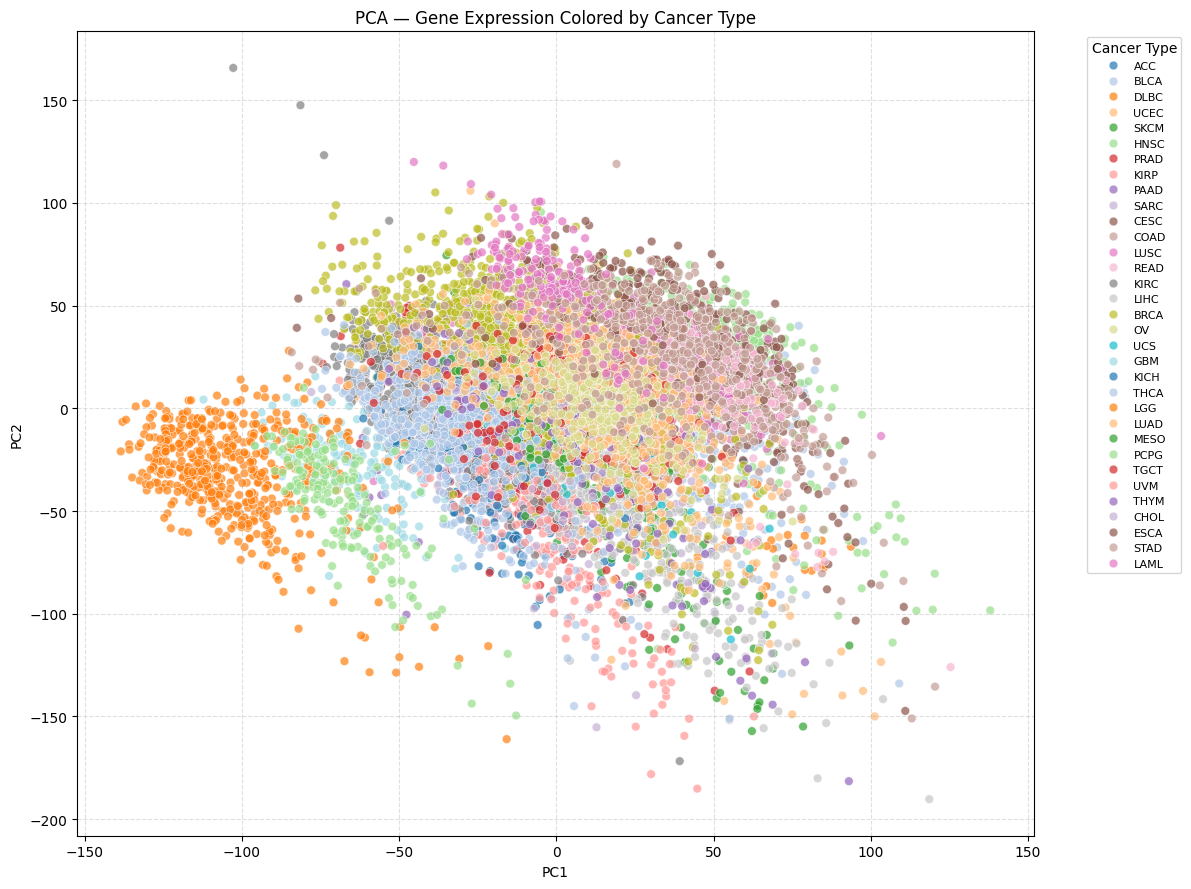

Observation: Samples of the same cancer type tend to cluster together,
confirming that gene expression profiles are cancer-type-specific.


In [24]:
from sklearn.decomposition import PCA
# 2-component PCA for 2D visualization only (not for modeling)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

y = final_df['cancer type abbreviation']

# Build a DataFrame for Seaborn
pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_df['Cancer Type'] = y.values

# Scatter plot colored by cancer type
plt.figure(figsize=(12, 9))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='Cancer Type',
    palette='tab20',
    s=40, alpha=0.7
)
plt.title('PCA — Gene Expression Colored by Cancer Type')
plt.legend(title='Cancer Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("Observation: Samples of the same cancer type tend to cluster together,")
print("confirming that gene expression profiles are cancer-type-specific.")

<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">🥧 Proportion of Cancer Types (Donut Chart)</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">Distribution of samples across all 33 cancer types in the dataset. This visualization helps identify class imbalance, which is important for choosing appropriate evaluation metrics in classification.</p>
</div>

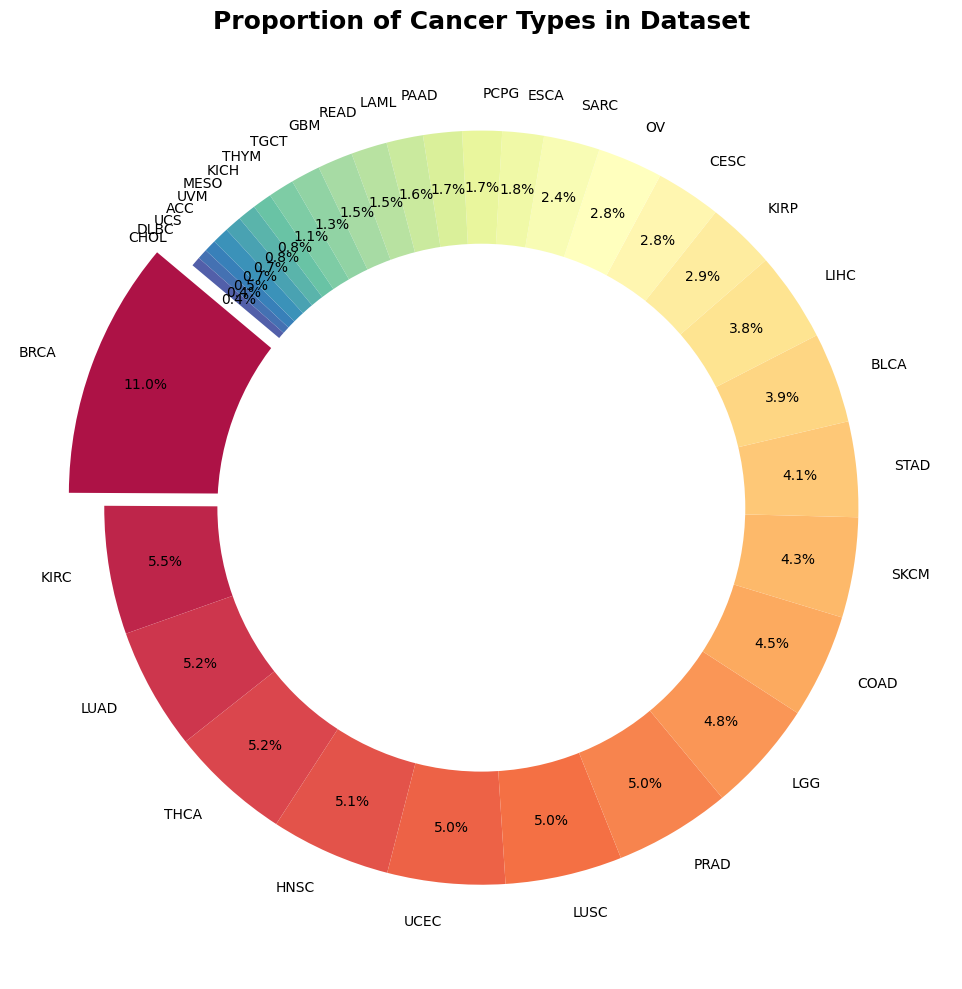

In [25]:
cancer_counts = final_df['cancer type abbreviation'].value_counts()
colors = sns.color_palette('pastel')[0:len(cancer_counts)]

plt.figure(figsize=(10, 10))
plt.pie(
    cancer_counts,
    labels=cancer_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("Spectral", len(cancer_counts)),
    pctdistance=0.85,
    explode=[0.1 if i == 0 else 0 for i in range(len(cancer_counts))] # تفجير أكبر شريحة
)

# إضافة الدائرة البيضاء في المنتصف لتحويلها لـ Donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proportion of Cancer Types in Dataset', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">🔬 Signature Biomarkers — Most Expressed Gene per Cancer Type</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">The "signature gene" with the highest average expression for each cancer type. These genes can serve as potential biological markers specific to each cancer.</p>
</div>

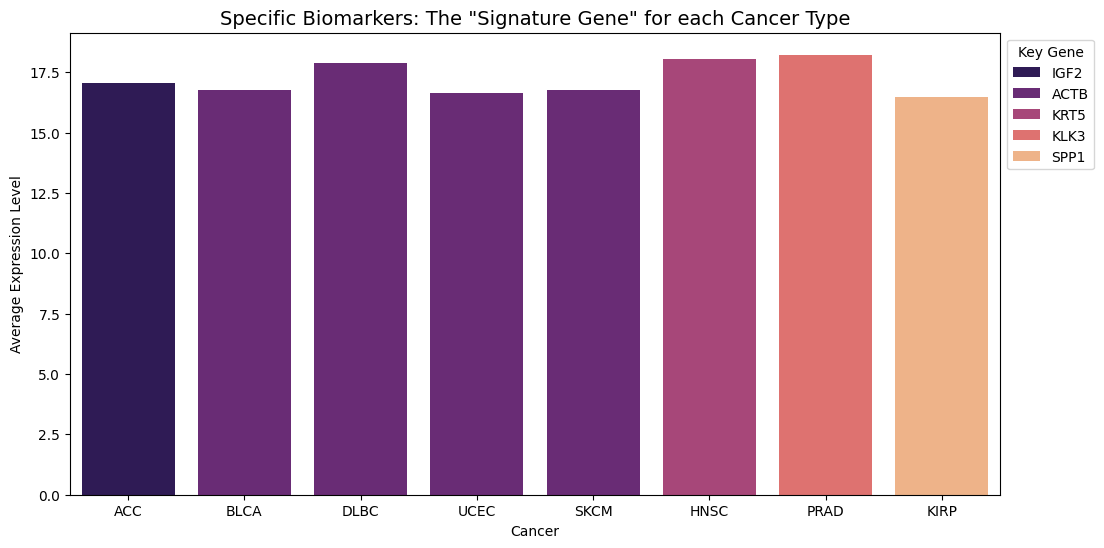

In [26]:
# كود لاستخراج أقوى جين لكل نوع سرطان ورسمه
top_markers = []
for cancer in final_df['cancer type abbreviation'].unique()[:8]: # سنأخذ أول 8 أنواع للتبسيط
    # نجد الجين الذي يمتلك أعلى متوسط في هذا النوع مقارنة بالبقية
    avg_exp = final_df[final_df['cancer type abbreviation'] == cancer][X.columns].mean()
    best_gene = avg_exp.idxmax()
    top_markers.append({'Cancer': cancer, 'Gene': best_gene, 'Expression': avg_exp.max()})

markers_df = pd.DataFrame(top_markers)

plt.figure(figsize=(12, 6))
sns.barplot(data=markers_df, x='Cancer', y='Expression', hue='Gene', palette='magma')
plt.title('Specific Biomarkers: The "Signature Gene" for each Cancer Type', fontsize=14)
plt.ylabel('Average Expression Level')
plt.legend(title='Key Gene', bbox_to_anchor=(1, 1))
plt.show()

<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">📊 Top 10 Most Variable Genes</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">Genes with the highest variance across all patients. These are the most informative genes for distinguishing between different cancer types and are excellent candidates for feature selection.</p>
</div>

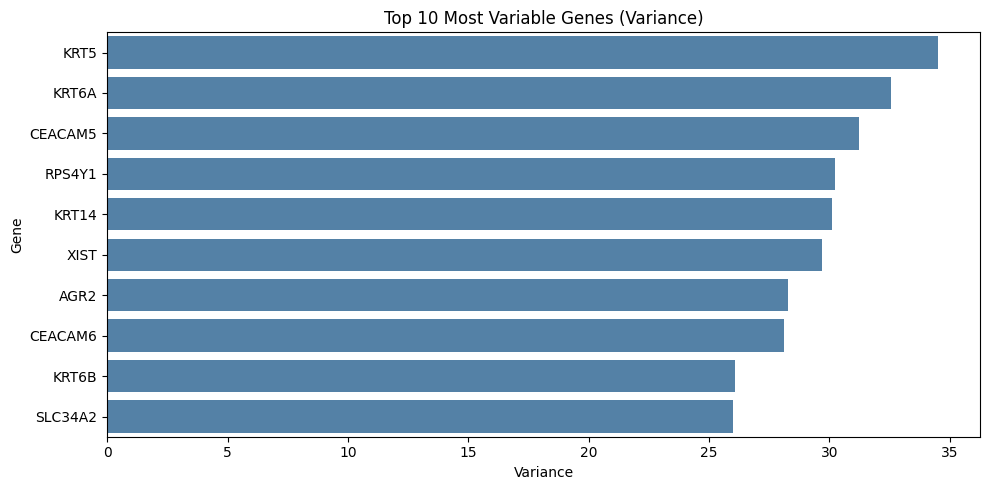

In [27]:
# Top 10 genes by variance
variances = X.var().sort_values(ascending=False).head(10)
var_df = pd.DataFrame({'Gene': variances.index, 'Variance': variances.values})

plt.figure(figsize=(10, 5))
sns.barplot(data=var_df, x='Variance', y='Gene', color='steelblue')
plt.title('Top 10 Most Variable Genes (Variance)')
plt.tight_layout()
plt.show()

<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">📋 Patient Distribution per Cancer Type</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">Number of patients for each cancer type. This bar chart clearly shows the class distribution and helps assess the degree of imbalance in the dataset.</p>
</div>

/tmp/ipykernel_6681/505082434.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cancer_counts, x='Cancer Type', y='Patient Count', palette='magma')


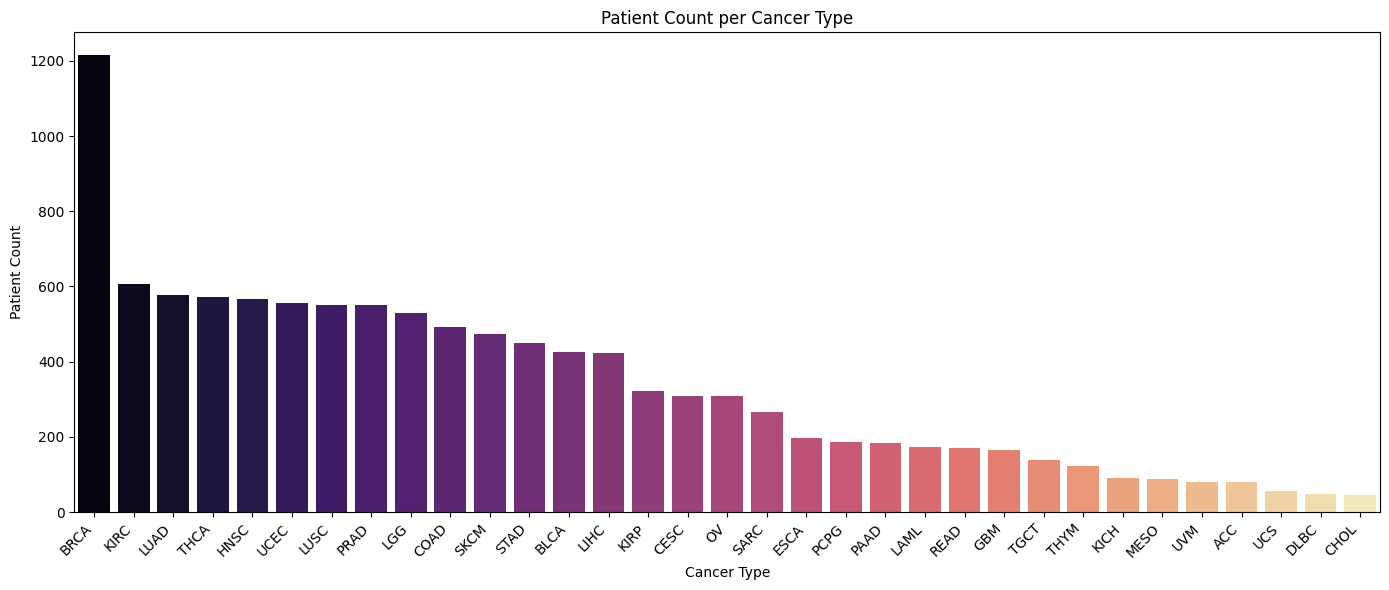

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Frequency table
cancer_counts = (
    final_df['cancer type abbreviation']
    .value_counts()
    .reset_index()
)
cancer_counts.columns = ['Cancer Type', 'Patient Count']

# Bar chart of patient counts per cancer type
plt.figure(figsize=(14, 6))
sns.barplot(data=cancer_counts, x='Cancer Type', y='Patient Count', palette='magma')
plt.title('Patient Count per Cancer Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<div style="background-color: #2d1a19; color: #f19bea; padding: 20px; border-left: 10px double #f19bea; border-right: 2px solid #f19bea; border-top: 2px solid #f19bea; border-bottom: 2px solid #f19bea; border-radius: 15px; max-width: 95%; margin: 20px auto; box-shadow: 0 5px 15px rgba(0,0,0,0.3); font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 130%; display: block; margin-bottom: 15px;">🏷️ Label Encoding</b>
  <p style="margin-left: 10px; color: #ffd6f7; opacity: 0.9; line-height: 1.8;">Converting cancer type labels into numeric format for machine learning models.</p>
</div>

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode cancer type strings → integer labels
y_encoded = le.fit_transform(final_df['cancer type abbreviation'])
final_df['cancer_label'] = y_encoded

# Print the full encoding map
encoding_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Cancer Type → Integer Label Mapping:")
for abbrev, code in encoding_map.items():
    en = cancer_map_en.get(abbrev, 'Unknown')
    ar = cancer_map_ar.get(abbrev, 'غير معروف')
    print(f"  {abbrev:6s} = {code:2d}  |  {en}  |  {ar}")

print(f"\nTotal classes : {len(le.classes_)}")
print(f"Shape of y    : {y_encoded.shape}")
print(f"Shape of X_pca: {X_pca_full.shape}")

Cancer Type → Integer Label Mapping:
  ACC    =  0  |  Adrenocortical Carcinoma  |  سرطان قشرة الأدرينال
  BLCA   =  1  |  Bladder Urothelial Carcinoma  |  سرطان المثانة
  BRCA   =  2  |  Breast Invasive Carcinoma  |  سرطان الثدي
  CESC   =  3  |  Cervical Squamous Cell Carcinoma  |  سرطان عنق الرحم الحرشفي
  CHOL   =  4  |  Cholangiocarcinoma  |  سرطان القنوات الصفراوية
  COAD   =  5  |  Colon Adenocarcinoma  |  سرطان القولون
  DLBC   =  6  |  Diffuse Large B-cell Lymphoma  |  سرطان الغدد الليمفاوية ب المساعد
  ESCA   =  7  |  Esophageal Carcinoma  |  سرطان المريء
  GBM    =  8  |  Glioblastoma Multiforme  |  سرطان الدماغ - إسفنجي
  HNSC   =  9  |  Head and Neck Squamous Cell Carcinoma  |  سرطان الرأس والرقبة
  KICH   = 10  |  Kidney Chromophobe  |  سرطان الكلى - فوبيا
  KIRC   = 11  |  Kidney Renal Clear Cell Carcinoma  |  سرطان الكلى - خلايا صافية
  KIRP   = 12  |  Kidney Renal Papillary Cell Carcinoma  |  سرطان الكلى الحليمي
  LAML   = 13  |  Acute Myeloid Leukemia  |  سرطان الدم ا

<div style="background: linear-gradient(135deg, #1a0a09 0%, #2d1a19 50%, #1a0a09 100%); color: #f19bea; padding: 30px; border-radius: 20px; text-align: center; border: 2px solid #f19bea; box-shadow: 0 0 40px rgba(241,155,234,0.3); font-family: 'Segoe UI', sans-serif; margin: 30px 0;">
  <h2 style="font-size: 180%; margin: 0 0 20px 0;">✅ Project Summary</h2>
  <p style="font-size: 110%; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #ffd6f7;">
    The TCGA Pan-Cancer dataset has been successfully loaded, cleaned, explored, and preprocessed.
    Dimensionality reduction using Variance Thresholding and PCA has been applied, and the data is now ready
    for multi-class classification modeling (Random Forest, XGBoost, Neural Networks, etc.).
  </p>
  <p style="margin-top: 20px; font-size: 95%; opacity: 0.8;">All steps were performed following scientific and programming best practices.</p>
</div>

## Milestone 3

# Model Tuning



Step 1: Duplicates the abbreviation column into a new column called parent_label.

Step 2: Uses a dictionary to group specific cancer types (like Colon and Rectal) into broader categories.

Step 3: Uses LabelEncoder to convert these text labels into numerical format, which is required for machine learning models to process the data.

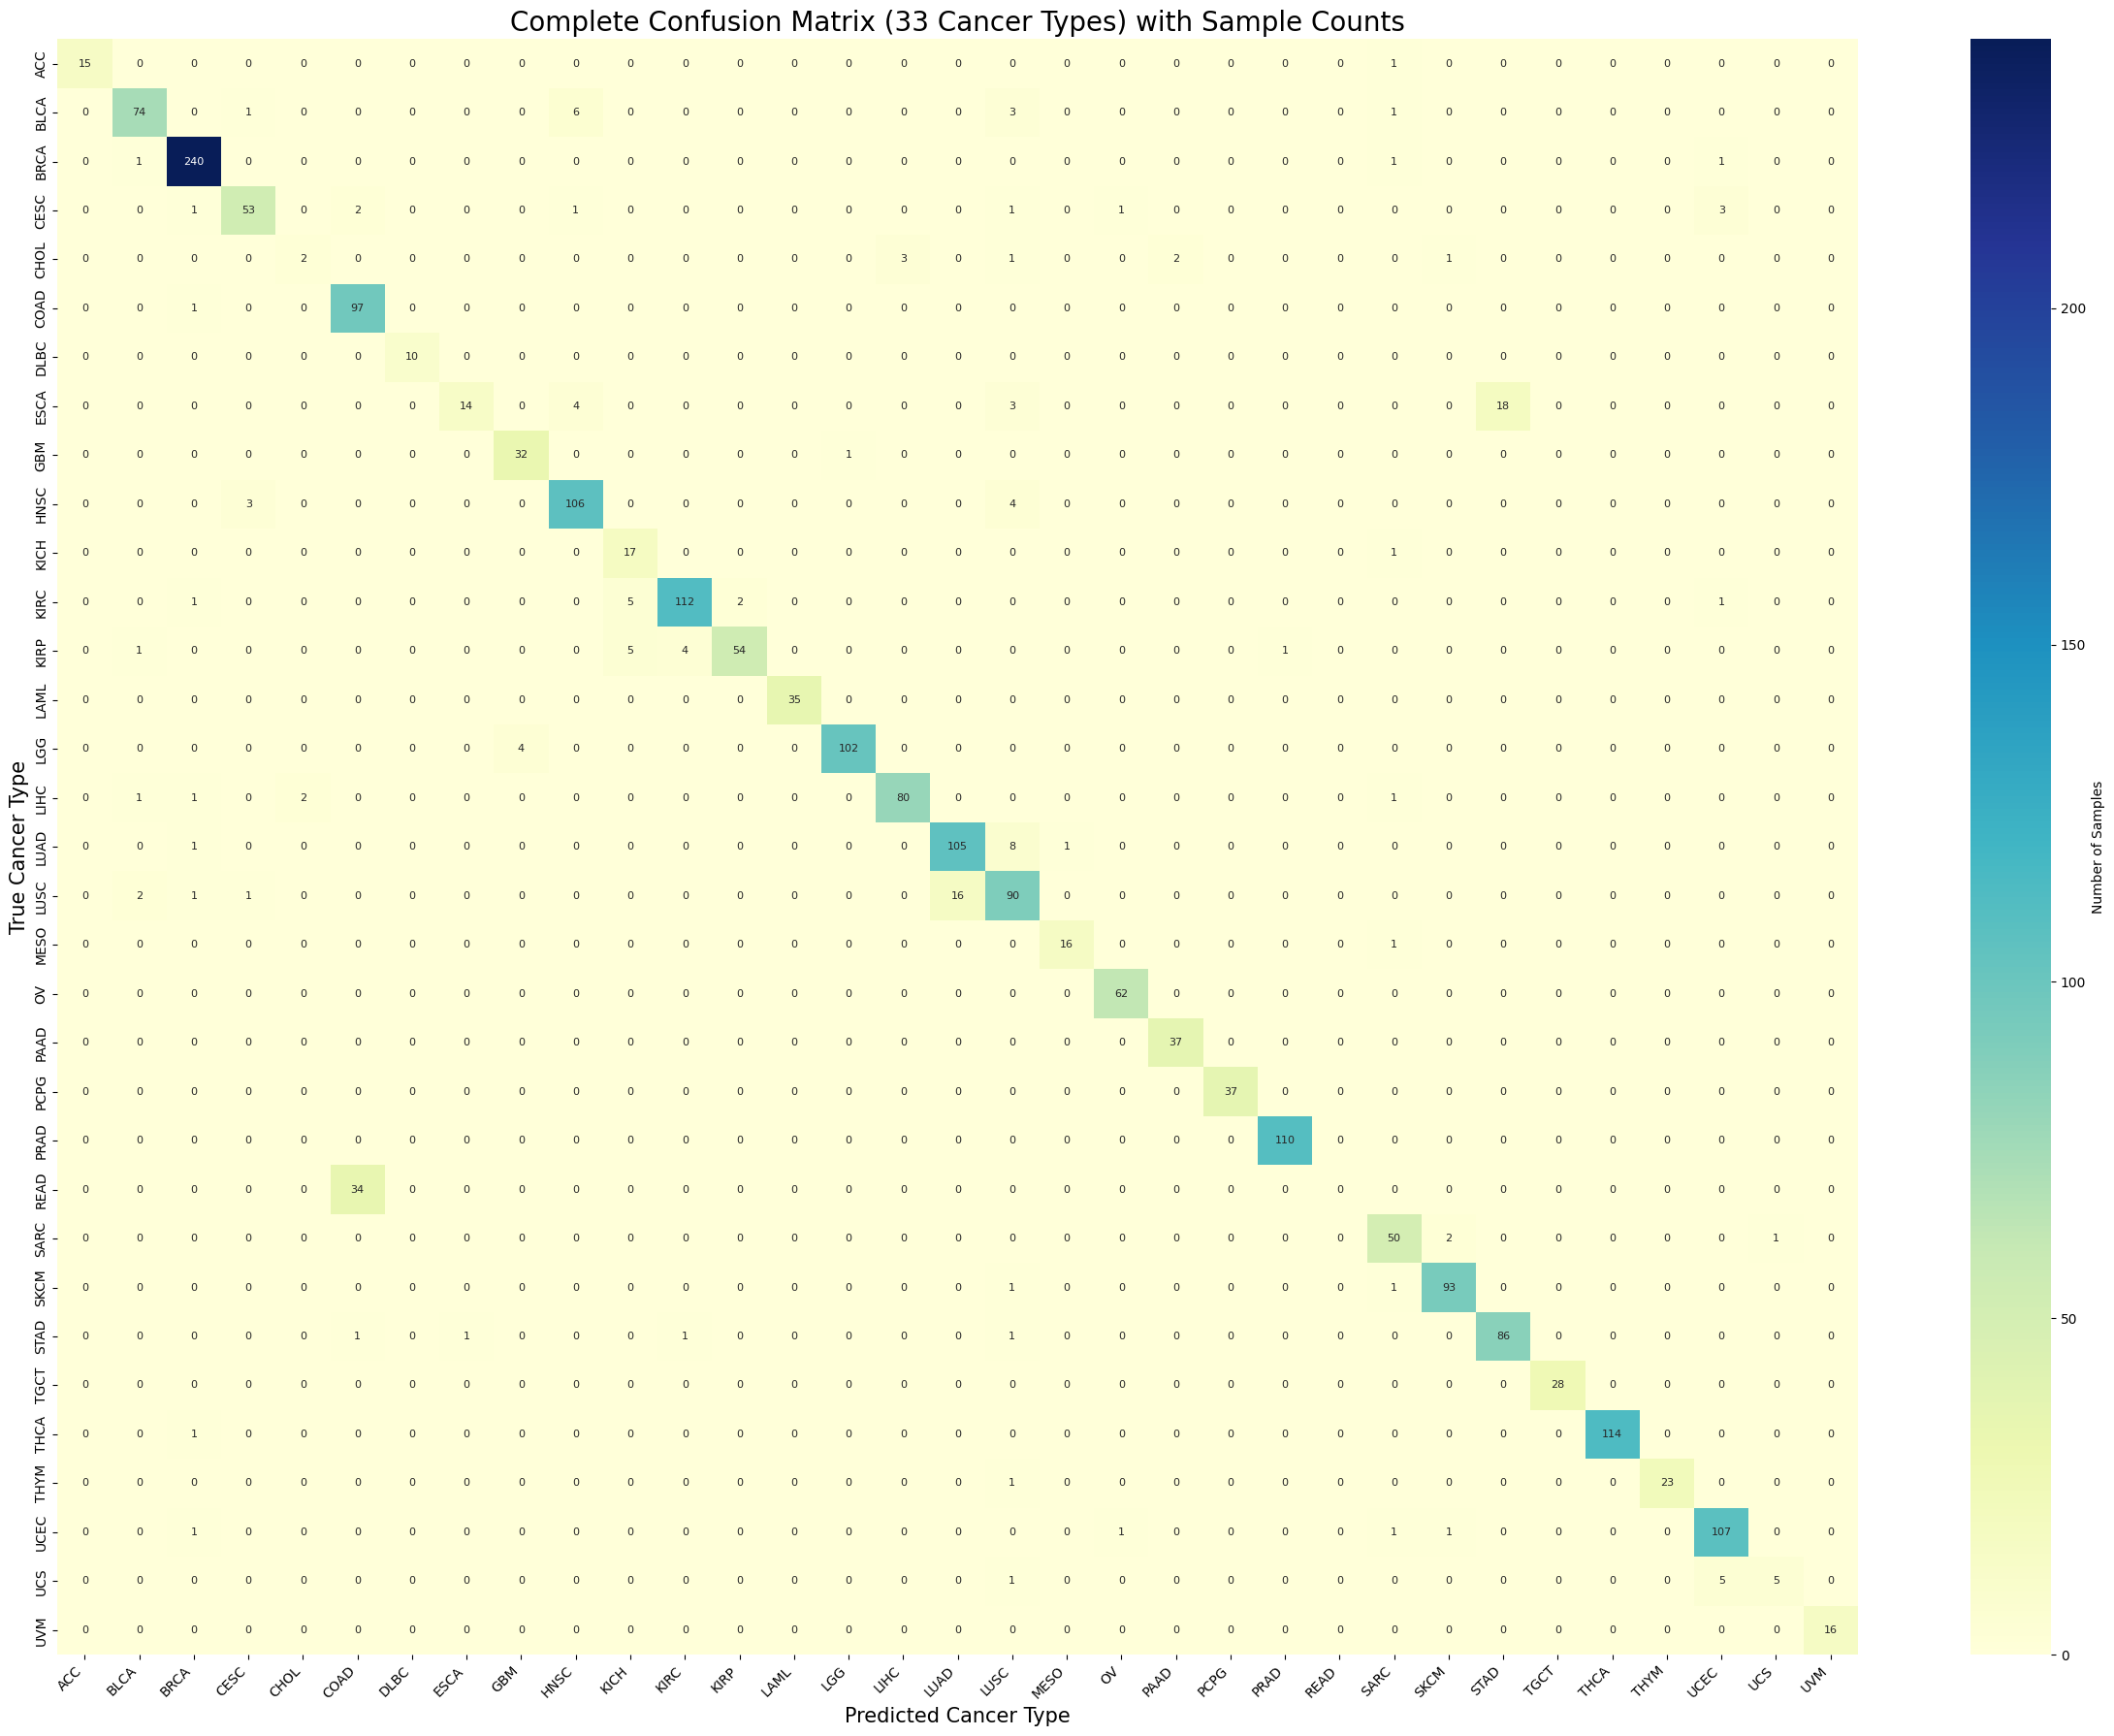

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. حساب المصفوفة للـ 33 نوعاً (قبل الدمج)
cm_all = confusion_matrix(y_test_pre, y_pred_pre)
labels = rf_check.classes_

# 2. رسم المصفوفة بحجم كبير جداً لضمان وضوح الأرقام
plt.figure(figsize=(24, 18)) # حجم ضخم ليتسع لـ 1089 مربع

sns.heatmap(cm_all,
            annot=True,          # تفعيل الأرقام
            fmt='d',             # عرض الأرقام كأعداد صحيحة
            cmap='YlGnBu',       # تدريج لوني مريح للعين (أصفر للأخضر للأزرق)
            annot_kws={"size": 8}, # تصغير حجم خط الأرقام داخل المربعات لتناسب المساحة
            xticklabels=labels,
            yticklabels=labels,
            cbar_kws={'label': 'Number of Samples'})

plt.title('Complete Confusion Matrix (33 Cancer Types) with Sample Counts', fontsize=20)
plt.xlabel('Predicted Cancer Type', fontsize=15)
plt.ylabel('True Cancer Type', fontsize=15)

# تدوير الأسماء بزاوية 45 درجة لتجنب التداخل
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [33]:
# 1. Create parent categories
final_df['parent_label'] = final_df['cancer type abbreviation']

# 2. Merge similar categories
mapping = {
    'COAD': 'COLORECTAL', 'READ': 'COLORECTAL',
    'LUAD': 'LUNG_CANCER', 'LUSC': 'LUNG_CANCER'
}
final_df['parent_label'] = final_df['parent_label'].replace(mapping)

# 3. Define the missing variable 'y_parent_encoded'
from sklearn.preprocessing import LabelEncoder
le_parent = LabelEncoder()
y_parent_encoded = le_parent.fit_transform(final_df['parent_label'])

print("✅ Success! 'y_parent_encoded' is now defined and ready.")
print(f"✅ Data Grouped: {len(le_parent.classes_)} Classes (Merged COAD/READ & LUAD/LUSC)")

✅ Success! 'y_parent_encoded' is now defined and ready.
✅ Data Grouped: 31 Classes (Merged COAD/READ & LUAD/LUSC)


#Model Training & Evaluationn:
 It includes the imports for the Random Forest Classifier and evaluation metrics (Accuracy, F1-score, and the Classification Report), which suggests you are about to start training the model.

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

# 1. Data Splitting
print("📊 Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_full, y_parent_encoded, test_size=0.2, random_state=42, stratify=y_parent_encoded
)

print("🔄 Training Parent Random Forest (Balanced Classes)...\n")

# 2. Model Initialization
rf_parent = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 3. Model Fitting
rf_parent.fit(X_train, y_train)

# 4. Prediction
y_pred = rf_parent.predict(X_test)

# 5. Metrics Calculation
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print("📊 RESULTS - Parent Model (Grouped Classes)")
print(f"Accuracy          : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"F1-weighted       : {f1_weighted:.4f}")

 # 6. Detailed Classification Report
print("\n" + "="*60)
print("Detailed Classification Report (Parent Model):")
print(classification_report(y_test, y_pred, target_names=le_parent.classes_, digits=3, zero_division=0))

📊 Splitting data into training and testing sets...
🔄 Training Parent Random Forest (Balanced Classes)...

📊 RESULTS - Parent Model (Grouped Classes)
Accuracy          : 0.9433  (94.33%)
F1-weighted       : 0.9408

Detailed Classification Report (Parent Model):
              precision    recall  f1-score   support

         ACC      1.000     0.938     0.968        16
        BLCA      0.986     0.824     0.897        85
        BRCA      0.972     0.984     0.978       243
        CESC      0.902     0.887     0.894        62
        CHOL      0.571     0.444     0.500         9
  COLORECTAL      0.970     0.985     0.977       132
        DLBC      1.000     1.000     1.000        10
        ESCA      0.875     0.359     0.509        39
         GBM      0.969     0.939     0.954        33
        HNSC      0.879     0.903     0.891       113
        KICH      0.842     0.889     0.865        18
        KIRC      0.950     0.942     0.946       121
        KIRP      0.967     0.908   

# Model Visualization: Confusion Matrix

The dark green squares running from the top-left to the bottom-right represent Correct Predictions. Any numbers outside that diagonal line represent Misclassifications

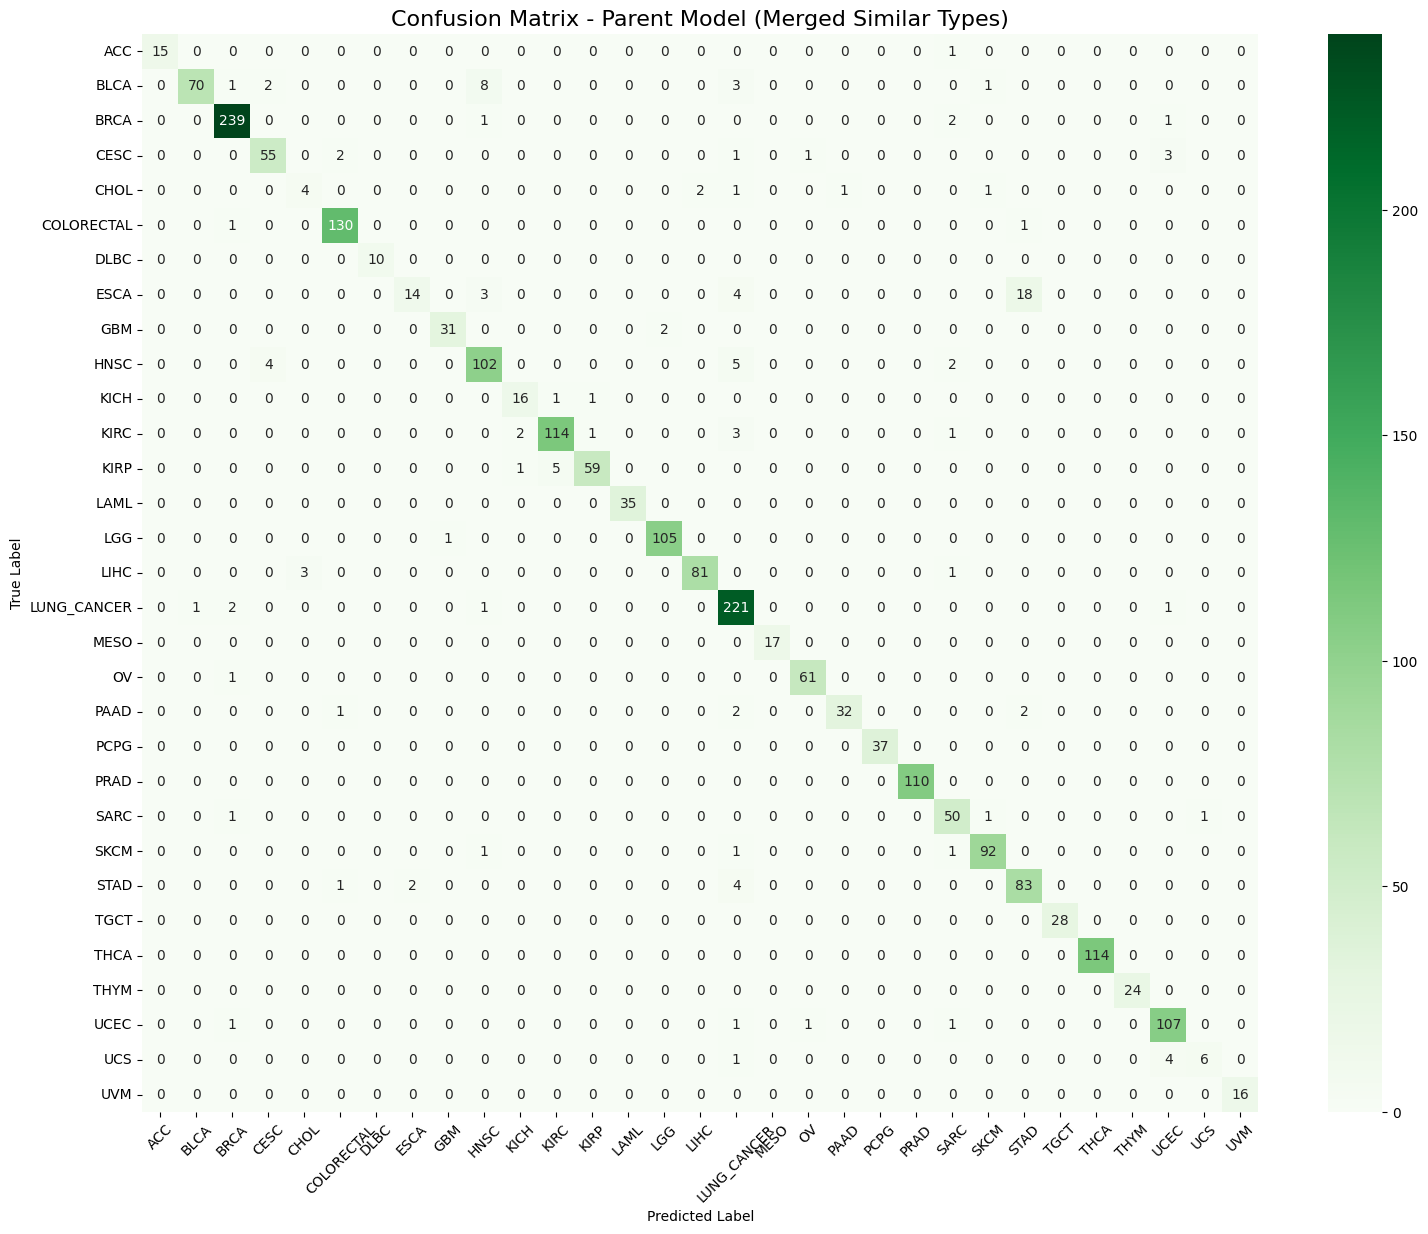

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(18, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_parent.classes_,
            yticklabels=le_parent.classes_)

plt.title('Confusion Matrix - Parent Model (Merged Similar Types)', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# **Hierarchical Classification**

Instead of asking one model to distinguish between 30+ types at once, you use this "Expert" to specifically handle the tricky distinction between COAD (Colon Adenocarcinoma) and READ (Rectum Adenocarcinoma) after they have been identified as Colorectal.

In [41]:
from sklearn.metrics import classification_report

# 1. Prepare data for the "Colorectal Expert" model
# We filter the samples that are originally COAD or READ
sub_data = final_df[final_df['cancer type abbreviation'].isin(['COAD', 'READ'])]
X_sub = X_pca_full[sub_data.index]
y_sub = sub_data['cancer type abbreviation']

# 2. Split and train the specialized model
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sub, y_sub, test_size=0.2, stratify=y_sub, random_state=42
)

colorectal_expert = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
colorectal_expert.fit(X_train_s, y_train_s)

# 3. Test the Expert model
y_pred_s = colorectal_expert.predict(X_test_s)
print("📊 Colorectal Expert Results (COAD vs READ):")
print(classification_report(y_test_s, y_pred_s, zero_division=0))

📊 Colorectal Expert Results (COAD vs READ):
              precision    recall  f1-score   support

        COAD       0.74      1.00      0.85        99
        READ       0.00      0.00      0.00        34

    accuracy                           0.74       133
   macro avg       0.37      0.50      0.43       133
weighted avg       0.55      0.74      0.64       133



#**Specialist Model: Refining COAD vs. READ Classification**

In [42]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. تحديد عينات القولون والمستقيم فقط من البيانات الأصلية (قبل الـ PCA العام)
# ملاحظة: نستخدم X_scaled (البيانات الموحدة لـ 20 ألف جين) لضمان أعلى دقة
colorectal_mask = final_df['cancer type abbreviation'].isin(['COAD', 'READ'])
X_raw_sub = X_scaled[colorectal_mask]
y_raw_sub = final_df.loc[colorectal_mask, 'cancer type abbreviation']

print(f"📊 Starting Specialist Model for {y_raw_sub.value_counts().to_dict()}")

# 2. Feature Selection (Microscope Effect)
selector = SelectKBest(score_func=f_classif, k=500)
X_selected = selector.fit_transform(X_raw_sub, y_raw_sub)

selected_features_count = sum(selector.get_support())
print(f"✅ Feature Selection Complete: {selected_features_count} features selected.")

# 3. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_raw_sub, test_size=0.2, stratify=y_raw_sub, random_state=42
)

# 4. Handle Imbalance using SMOTE
print("🔄 Balancing classes with SMOTE...")
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# 5. Train the Specialist Random Forest
print("🚀 Training Final Specialist Model...")
specialist_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
specialist_rf.fit(X_train_res, y_train_res)

# 6. Final Evaluation
y_pred = specialist_rf.predict(X_test)

print("\n" + "="*40)
print("🔥 FINAL SPECIALIST RESULTS (COAD vs READ)")
print("="*40)
print(classification_report(y_test, y_pred, target_names=['COAD', 'READ'], zero_division=0))

📊 Starting Specialist Model for {'COAD': 492, 'READ': 170}
✅ Feature Selection Complete: 500 features selected.
🔄 Balancing classes with SMOTE...
🚀 Training Final Specialist Model...


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 7661  7662  7663  7664  7665 15139 15141 15142 16570 16698 16700 16701
 16702 16704 16705 16706 16707 16708 16709 16710 16711 16712 16713 16714
 16715 16716 16717 16718 16719 16720 16721 16722 16723 16724 16725 16726
 16727 16728 16729 16730 16731 16732 16733 16734 16735 16736 16737 16738
 16739 16740 16741 16742 16743 16744 16745 16746 16747 16749 16750 16751
 16752 16754 16755 16756 16758 16759 16760 16761 16762 16763 16764 16765
 16766 16767 16768 16769 16770 16771 16772 16773 16775 16776 16777 16778
 16779 16780 16781 16782 16783 16784 16785 16788 16789 16790 16791 16792
 16793 16794 16796 16797 16799 16800 16801 16802 16803 16804 16805 16806
 16807 16808 16809 16810 16811 16812 16814 16817 16819 16820 16821 16822
 16823 16824 16825 16827 16828 16831 16832 16833 16834 16835 16836 16837
 16838 16839 16840 16841 16842 16843 16844 16845 16846 16847 16848 16849
 16850


🔥 FINAL SPECIALIST RESULTS (COAD vs READ)
              precision    recall  f1-score   support

        COAD       0.85      0.83      0.84        99
        READ       0.54      0.59      0.56        34

    accuracy                           0.77       133
   macro avg       0.70      0.71      0.70       133
weighted avg       0.77      0.77      0.77       133



# Hierarchical Classification: Lung Cancer Expert

In [43]:
from sklearn.metrics import classification_report

# 1. Prepare data for the "Lung Expert" model
# Filtering the dataset for Lung Adenocarcinoma (LUAD) and Lung Squamous Cell Carcinoma (LUSC)
lung_sub_data = final_df[final_df['cancer type abbreviation'].isin(['LUAD', 'LUSC'])]
X_lung_sub = X_pca_full[lung_sub_data.index]
y_lung_sub = lung_sub_data['cancer type abbreviation']

# 2. Specialized Train/Test Split
# We split only the lung-specific data to train the expert model
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_lung_sub, y_lung_sub, test_size=0.2, stratify=y_lung_sub, random_state=42
)

# 3. Training the Lung Expert
# Using a Random Forest with 200 trees and balanced class weights
lung_expert = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
lung_expert.fit(X_train_l, y_train_l)

# 4. Evaluation
y_pred_l = lung_expert.predict(X_test_l)
print("📊 Lung Expert Results (LUAD vs LUSC):")
print(classification_report(y_test_l, y_pred_l, target_names=['LUAD', 'LUSC'], zero_division=0))

📊 Lung Expert Results (LUAD vs LUSC):
              precision    recall  f1-score   support

        LUAD       0.89      0.96      0.92       115
        LUSC       0.95      0.87      0.91       111

    accuracy                           0.92       226
   macro avg       0.92      0.92      0.92       226
weighted avg       0.92      0.92      0.92       226



# Feature Importance Analysis

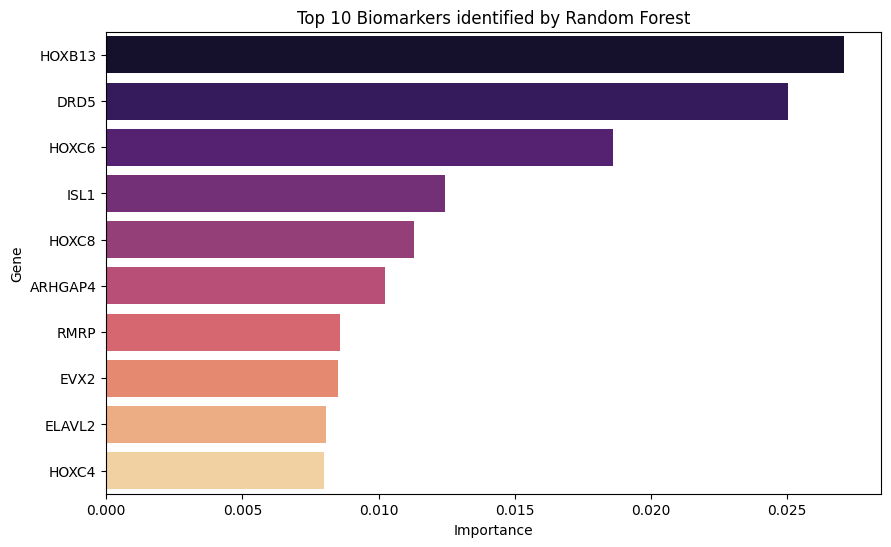

In [46]:
importances = specialist_rf.feature_importances_

# Get the original gene names from X and apply the selector's mask
original_gene_columns = X.columns
selected_feature_mask = selector.get_support()
feature_names = original_gene_columns[selected_feature_mask]

# 2. Sort and store the top 10 genes
feature_importance_df = pd.DataFrame({
    'Gene': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Gene', hue='Gene', data=feature_importance_df.head(10), palette='magma', legend=False)
plt.title('Top 10 Biomarkers identified by Random Forest')
plt.show()

# **Alternative Model: Support Vector Machine (SVM)**

In [47]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

# 1. تجهيز البيانات (نفس التقسيم المستخدم سابقاً لضمان عدالة المقارنة)
# سنستخدم X_pca_full و y_parent_encoded
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_pca_full, y_parent_encoded, test_size=0.2, random_state=42, stratify=y_parent_encoded
)

# 2. Initialize and Train the SVM Model
# نستخدم kernel='linear' لأنه الأفضل مع بيانات الجينات
# class_weight='balanced' للتعامل مع عدم توازن الفئات
svm_model = SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=42)

print("🔄 Training SVM Classifier (this might take a few minutes)...")
svm_model.fit(X_train_svm, y_train_svm)

# 3. Prediction
y_pred_svm = svm_model.predict(X_test_svm)

# 4. Final Results
svm_acc = accuracy_score(y_test_svm, y_pred_svm)
print(f"✅ SVM Accuracy: {svm_acc:.4f} ({svm_acc*100:.2f}%)")
print("\nDetailed Classification Report (SVM):")
print(classification_report(y_test_svm, y_pred_svm, target_names=le_parent.classes_))

🔄 Training SVM Classifier (this might take a few minutes)...
✅ SVM Accuracy: 0.9732 (97.32%)

Detailed Classification Report (SVM):
              precision    recall  f1-score   support

         ACC       1.00      1.00      1.00        16
        BLCA       0.98      0.99      0.98        85
        BRCA       1.00      0.98      0.99       243
        CESC       0.95      0.94      0.94        62
        CHOL       1.00      0.44      0.62         9
  COLORECTAL       0.98      0.99      0.99       132
        DLBC       1.00      1.00      1.00        10
        ESCA       0.83      0.90      0.86        39
         GBM       1.00      1.00      1.00        33
        HNSC       1.00      0.98      0.99       113
        KICH       0.76      0.89      0.82        18
        KIRC       0.97      0.95      0.96       121
        KIRP       0.92      0.91      0.91        65
        LAML       1.00      1.00      1.00        35
         LGG       1.00      1.00      1.00       106
   

# Hyperparameter Tuning with GridSearchCV

Grid Search is the systematic process of finding the absolute best settings (hyperparameters) for your model to achieve the highest possible accuracy.

In [48]:
from sklearn.model_selection import GridSearchCV

# تحديد العوامل التي نريد تجربتها (مثلاً قيم مختلفة لـ C)
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear']
}

print("🔍 Starting Hyperparameter Tuning (Grid Search)...")
grid_search = GridSearchCV(SVC(class_weight='balanced'), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train_svm, y_train_svm)

print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best Cross-validation score: {grid_search.best_score_:.4f}")

# الموديل النهائي المحسن
final_tuned_svm = grid_search.best_estimator_

🔍 Starting Hyperparameter Tuning (Grid Search)...
Best Parameters found: {'C': 0.1, 'kernel': 'linear'}
Best Cross-validation score: 0.9734


# **Final Model Comparison: Random Forest vs. SVM**
we compared the Random Forest and Support Vector Machine (SVM) classifiers.

SVM Accuracy: 97.32%

Random Forest Accuracy: 94.33%

📋 Final Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.943259,0.944201,0.943259,0.940756
1,SVM,0.973218,0.974013,0.973218,0.973018


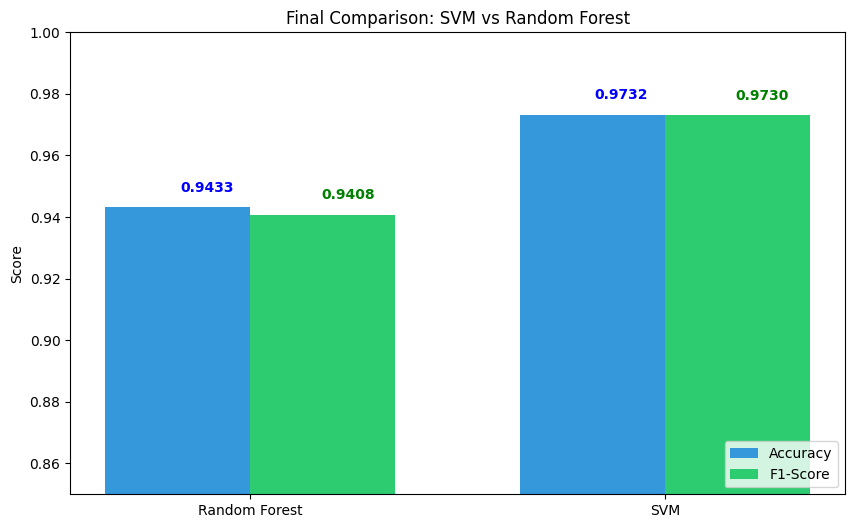

In [49]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as npٍ
import pandas as pd

# 1. Define models for comparison
# Using 'rf_parent' (Random Forest) and 'svm_model' (SVM)
models_to_compare = {
    'Random Forest': rf_parent,
    'SVM': svm_model
}

report_data = []

for name, model in models_to_compare.items():
    # التنبؤ باستخدام بيانات الاختبار الخاصة بكل موديل
    y_pred_temp = model.predict(X_test_svm)

    acc = accuracy_score(y_test_svm, y_pred_temp)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test_svm, y_pred_temp, average='weighted')

    report_data.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# 2. Display the summary table
comparison_df = pd.DataFrame(report_data)
print("📋 Final Model Comparison Table:")
display(comparison_df)

# 3. Visual Comparison (Bar Chart)
plt.figure(figsize=(10, 6))
x = np.arange(len(comparison_df['Model']))
width = 0.35

# Plotting Accuracy and F1-Score
plt.bar(x - width/2, comparison_df['Accuracy'], width, label='Accuracy', color='#3498db')
plt.bar(x + width/2, comparison_df['F1-Score'], width, label='F1-Score', color='#2ecc71')

plt.xticks(x, comparison_df['Model'])
plt.ylabel('Score')
plt.title('Final Comparison: SVM vs Random Forest')
plt.legend(loc='lower right')
plt.ylim(0.85, 1.0)

# Add numerical values on top of bars
for i, v in enumerate(comparison_df['Accuracy']):
    plt.text(i - 0.17, v + 0.005, f"{v:.4f}", color='blue', fontweight='bold')
for i, v in enumerate(comparison_df['F1-Score']):
    plt.text(i + 0.17, v + 0.005, f"{v:.4f}", color='green', fontweight='bold')

plt.show()

# **Model Stability Validation (Cross-Validation)**

Cross-validation to ensure the model's ability to generalize

In [50]:
from sklearn.model_selection import cross_val_score

# 1. Validate the stability of the SVM model
# We use cv=5 to split the data into 5 different folds
# Each fold serves as a test set once while the model trains on the other 4

scores = cross_val_score(svm_model, X_pca_full, y_parent_encoded, cv=5)

#2. Output the results
print(f"Mean Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

Mean Accuracy: 0.9681
Standard Deviation: 0.0053


# Final Validation: Statistical Comparison (CV Box Plot)

SVM (which likely appears higher on the plot) is objectively better and more reliable than the Random Forest across various subsets of the gene data.

🔄 Calculating Cross-Validation scores (this may take a moment)...
✅ Random Forest: Mean Accuracy = 0.9405 (+/- 0.0084)
✅ SVM: Mean Accuracy = 0.9681 (+/- 0.0053)


/tmp/ipykernel_6681/360209381.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names, patch_artist=True,


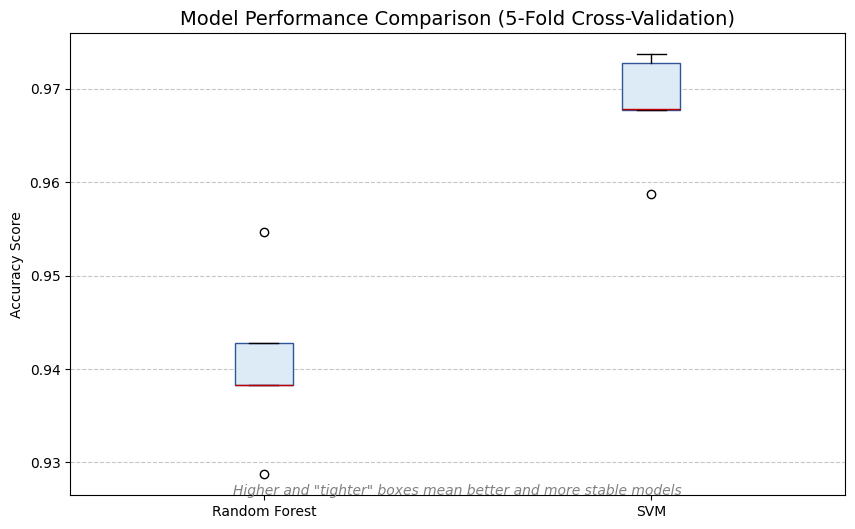

In [51]:
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define models for comparison
models = [
    ('Random Forest', rf_parent),
    ('SVM', svm_model)
]

results = []
names = []

print("🔄 Calculating Cross-Validation scores (this may take a moment)...")

for name, model in models:
    # إجراء التحقق المتقاطع (5-fold cross-validation)
    cv_scores = cross_val_score(model, X_pca_full, y_parent_encoded, cv=5, n_jobs=1)
    results.append(cv_scores)
    names.append(name)
    print(f"✅ {name}: Mean Accuracy = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 2. Visualize Comparison using a Box Plot
plt.figure(figsize=(10, 6))
plt.boxplot(results, labels=names, patch_artist=True,
            boxprops=dict(facecolor='#DDEBF7', color='#2F5597'),
            medianprops=dict(color='#C00000'))

plt.title('Model Performance Comparison (5-Fold Cross-Validation)', fontsize=14)
plt.ylabel('Accuracy Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a brief explanation to the plot
plt.text(1.5, plt.ylim()[0], 'Higher and "tighter" boxes mean better and more stable models',
         horizontalalignment='center', fontsize=10, style='italic', color='gray')

plt.show()